# Context Accumulation and Direction Displacement

Implements the analysis plan from `docs/experiment_design.md`.

**Figure 1 — Direction displacement across turns**
Does v_harmful rotate away from the single-turn baseline as context accumulates?
Three lines: drift from ST baseline, divergence from no-context, compressed reference.

**Figure 2 — Detection failure and recovery**
Does a fixed (single-turn) classifier degrade while a per-turn adaptive classifier holds?
AUROC at each turn k for fixed vs. adaptive projections.

**Figure 3 — Behavioral correlation**
Do compliant turns cluster at different projections than refused turns?

### Data requirements

| Condition | Source | Required for |
|-----------|--------|-------------|
| Full-context trajectory | nb03 `trajectories/` | Figs 1, 2, 3 |
| Single-turn baseline | nb03 `single_turn/` | Figs 1, 2 |
| No-context | nb07 `nocontext/` | Fig 1 (context contribution line) |
| Compressed | nb07 `compressed/` | Fig 1 (reference line) |

Figures 1 and 2 can be partially produced with just trajectory + single-turn.
No-context and compressed lines are added when that data is available.

In [ ]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODEL     = 'llama'   # model subdirectory under data/

REPR_ROOT = repo_root / 'data' / MODEL / 'representations'
CONV_ROOT = repo_root / 'data' / MODEL / 'conversations'
FIG_DIR   = repo_root / "figures"

FRAMEWORKS = ["crescendo", "actorattack", "xteaming"]
SPLITS     = ["harmful", "benign"]
N_LAYERS   = 32
HIDDEN_DIM = 4096

TRAIN_MAX_ATTEMPT = 16          # attempts 1-16 -> train; 17-20 -> test

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 200, "savefig.bbox": "tight"})
print(f"REPR_ROOT: {REPR_ROOT}")

# ── Load per-model layer sweep from layer_indices.json ──────────────────────
# After the down-select, saved arrays have shape (N, 8, D). layer_indices.json
# sits next to each (fw_split) directory with the original transformer-layer IDs.
import json as _json

def _load_layer_info(model_root):
    for sub in ("trajectories", "nocontext", "single_turn"):
        root = model_root / sub
        if not root.exists():
            continue
        for d in root.iterdir():
            fp = d / "layer_indices.json"
            if fp.exists():
                return _json.loads(fp.read_text())
    raise FileNotFoundError(
        f"No layer_indices.json under {model_root} — run scripts/downselect_layers.py"
    )

_LAYER_INFO        = _load_layer_info(REPR_ROOT)
N_SAVED_LAYERS     = _LAYER_INFO["n_sweep"]
VERIFY_LAYERS      = list(range(N_SAVED_LAYERS))       # saved-array positions 0..7
VERIFY_LABELS      = _LAYER_INFO["labels"]             # e.g. ["L1", "L5", "L9", ...]
N_VERIFY           = N_SAVED_LAYERS
FOCAL_LAYER        = N_SAVED_LAYERS - 1                # last saved layer (deepest); was L32 on Llama
FOCAL_LAYER_LABEL  = VERIFY_LABELS[FOCAL_LAYER]
ALL_LAYERS         = VERIFY_LAYERS                     # full sweep as saved
print(f"Saved-layer sweep: {VERIFY_LABELS}  |  focal={FOCAL_LAYER_LABEL}")


## Data loading

Load all available conditions.  Missing conditions (no-context, compressed)
are skipped with a warning — the plots will omit those lines.

In [ ]:
def load_repr(folder):
    """Load h_inst, h_post_inst, metadata from a representations folder."""
    meta   = pd.read_parquet(folder / "metadata.parquet")
    h_inst = np.load(folder / "h_inst.npy")            # float16
    h_post = np.load(folder / "h_post_inst.npy")       # float16
    assert len(meta) == len(h_inst) == len(h_post)
    return {"meta": meta, "h_inst": h_inst, "h_post": h_post}

def add_split_column(meta):
    """Add train/test split based on attempt number."""
    meta["data_split"] = np.where(
        meta["attempt"] <= TRAIN_MAX_ATTEMPT, "train", "test"
    )
    return meta

# ── Condition 1: Full-context trajectories ────────────────────────────────────
traj = {}
for fw in FRAMEWORKS:
    for split in SPLITS:
        folder = REPR_ROOT / "trajectories" / f"{fw}_{split}"
        if not folder.exists():
            print(f"  MISSING: {folder}")
            continue
        traj[(fw, split)] = load_repr(folder)
        add_split_column(traj[(fw, split)]["meta"])
        n = len(traj[(fw, split)]["meta"])
        print(f"  traj  {fw:14s} {split:8s}  rows={n:6d}")

avail_fw = sorted({fw for fw, _ in traj.keys()})
print(f"\nAvailable frameworks (trajectory): {avail_fw}")

# ── Condition 4: Single-turn baseline ─────────────────────────────────────────
st = {}
for split in SPLITS:
    folder = REPR_ROOT / "single_turn" / split
    if not folder.exists():
        print(f"  MISSING: {folder}")
        continue
    st[split] = load_repr(folder)
    print(f"  st    {split:8s}  rows={len(st[split]['meta']):6d}")

# ── Condition 2: No-context (from nb07) ───────────────────────────────────────
nc = {}
for fw in avail_fw:
    for split in SPLITS:
        folder = REPR_ROOT / "nocontext" / f"{fw}_{split}"
        if not folder.exists():
            continue
        nc[(fw, split)] = load_repr(folder)
        add_split_column(nc[(fw, split)]["meta"])
        print(f"  nc    {fw:14s} {split:8s}  rows={len(nc[(fw, split)]['meta']):6d}")

if not nc:
    print("  No-context data not yet extracted (run nb07).")

# ── Condition 3: Compressed (from nb07) ───────────────────────────────────────
comp = {}
for fw in avail_fw:
    for split in SPLITS:
        folder = REPR_ROOT / "compressed" / f"{fw}_{split}"
        if not folder.exists():
            continue
        comp[(fw, split)] = load_repr(folder)
        add_split_column(comp[(fw, split)]["meta"])
        print(f"  comp  {fw:14s} {split:8s}  rows={len(comp[(fw, split)]['meta']):6d}")

if not comp:
    print("  Compressed data not yet extracted (run nb07).")

print("\nDone loading.")

In [ ]:
# ── Per-turn behavioral labels from conversation JSONs ────────────────────────
# Needed for Figure 3.  Only Crescendo has is_refusal / judge_success fields.

def load_turn_labels(conv_dir):
    """Build a DataFrame of per-turn behavioral labels from conversation JSONs."""
    records = []
    for fpath in sorted(conv_dir.glob("*.json")):
        conv = json.load(open(fpath))
        turns = conv.get("turns", [])
        by_idx = {}
        for t in turns:
            by_idx.setdefault(t["turn_idx"], {})[t["role"]] = t

        k = 0
        for turn_idx in sorted(by_idx):
            pair = by_idx[turn_idx]
            user_t = pair.get("user")
            asst_t = pair.get("assistant")
            if not user_t or not asst_t:
                continue
            if user_t.get("rolled_back", False) or asst_t.get("rolled_back", False):
                continue
            k += 1
            records.append({
                "pair_id":       conv["objective_pair_id"],
                "attempt":       conv.get("attempt", 1),
                "turn_k":        k,
                "is_refusal":    bool(asst_t.get("is_refusal", False)),
                "judge_success": bool(asst_t.get("judge_success", False)),
            })
    return pd.DataFrame(records)

turn_labels = {}
for fw in avail_fw:
    harmful_dir = CONV_ROOT / f"{fw}_harmful"
    if not harmful_dir.exists():
        continue
    labels = load_turn_labels(harmful_dir)
    turn_labels[fw] = labels
    n_ref = labels["is_refusal"].sum()
    n_suc = labels["judge_success"].sum()
    print(f"  {fw}: {len(labels)} turn-labels  "
          f"(is_refusal={n_ref}, judge_success={n_suc})")

print("Done.")

## Direction computation

Within-pair subtraction: for each JBB pair, `diff = mean(harmful) - mean(benign)`,
then `v_harmful = normalize(mean(diffs))`. This cancels topic signal.

Train split only (attempts 1-16). Computed per turn k for trajectory and no-context,
once for single-turn and compressed.

In [ ]:
def compute_direction_paired(h_harm, m_harm, h_beni, m_beni):
    """
    Within-pair v_harmful.  Returns (32, 4096) unit-normalised float32,
    or None if no valid pairs.
    """
    pairs = sorted(set(m_harm["pair_id"]) & set(m_beni["pair_id"]))
    diffs = []
    for pid in pairs:
        idx_h = m_harm.index[m_harm["pair_id"] == pid].tolist()
        idx_b = m_beni.index[m_beni["pair_id"] == pid].tolist()
        if not idx_h or not idx_b:
            continue
        mu_h = h_harm[idx_h].astype(np.float32).mean(axis=0)  # (32, 4096)
        mu_b = h_beni[idx_b].astype(np.float32).mean(axis=0)
        diffs.append(mu_h - mu_b)
    if not diffs:
        return None
    d_mean = np.stack(diffs).mean(axis=0)
    norms  = np.linalg.norm(d_mean, axis=-1, keepdims=True)
    return d_mean / (norms + 1e-12)

def direction_at_k(data_dict, fw, h_key, k):
    """
    Compute within-pair direction at turn k from train split.
    data_dict: traj or nc dict keyed by (fw, split).
    h_key: 'h_inst' or 'h_post'.
    Returns (32, 4096) or None.
    """
    d_h = data_dict.get((fw, "harmful"))
    d_b = data_dict.get((fw, "benign"))
    if d_h is None or d_b is None:
        return None

    mask_h = (d_h["meta"]["turn_k"] == k) & (d_h["meta"]["data_split"] == "train")
    mask_b = (d_b["meta"]["turn_k"] == k) & (d_b["meta"]["data_split"] == "train")

    if mask_h.sum() == 0 or mask_b.sum() == 0:
        return None

    return compute_direction_paired(
        d_h[h_key][mask_h.values], d_h["meta"][mask_h].reset_index(drop=True),
        d_b[h_key][mask_b.values], d_b["meta"][mask_b].reset_index(drop=True),
    )

def direction_overall(data_dict, fw, h_key):
    """
    Direction from all train data (no turn_k filter).
    Used for compressed condition (one row per conv, no turn_k).
    """
    d_h = data_dict.get((fw, "harmful"))
    d_b = data_dict.get((fw, "benign"))
    if d_h is None or d_b is None:
        return None

    mask_h = d_h["meta"]["data_split"] == "train"
    mask_b = d_b["meta"]["data_split"] == "train"

    return compute_direction_paired(
        d_h[h_key][mask_h.values], d_h["meta"][mask_h].reset_index(drop=True),
        d_b[h_key][mask_b.values], d_b["meta"][mask_b].reset_index(drop=True),
    )

def cosine(a, b):
    """Cosine similarity between two vectors."""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

print("Direction helpers defined.")

In [ ]:
# ── Compute all directions ────────────────────────────────────────────────────

# Single-turn baseline (Condition 4): within-pair, all 100 goals
# (no attempt field, so no train/test split — all used for direction)
h_st_h = st["harmful"]["h_inst"].astype(np.float32)
h_st_b = st["benign"]["h_inst"].astype(np.float32)
m_st_h = st["harmful"]["meta"].sort_values("pair_id")
m_st_b = st["benign"]["meta"].sort_values("pair_id")
h_st_h_sorted = h_st_h[m_st_h.index]
h_st_b_sorted = h_st_b[m_st_b.index]

d_st = h_st_h_sorted - h_st_b_sorted                   # (100, 32, 4096)
d_st_mean = d_st.mean(axis=0)
norms_st = np.linalg.norm(d_st_mean, axis=-1, keepdims=True)
v_st_inst = d_st_mean / (norms_st + 1e-12)             # (32, 4096)

# Same for h_post
hp_st_h = st["harmful"]["h_post"].astype(np.float32)[m_st_h.index]
hp_st_b = st["benign"]["h_post"].astype(np.float32)[m_st_b.index]
d_st_p = hp_st_h - hp_st_b
d_st_p_mean = d_st_p.mean(axis=0)
norms_st_p = np.linalg.norm(d_st_p_mean, axis=-1, keepdims=True)
v_st_post = d_st_p_mean / (norms_st_p + 1e-12)

print(f"v_st_inst:  {v_st_inst.shape}")
print(f"v_st_post:  {v_st_post.shape}")

# Per-turn-k directions: full-context trajectory (Condition 1)
MAX_K = 10
v_full = {}   # v_full[(fw, h_key)][k] = (32, 4096) or None
n_at_k = {}   # sample sizes for annotation

for fw in avail_fw:
    for h_key in ["h_inst", "h_post"]:
        v_full[(fw, h_key)] = {}
        n_at_k[(fw, h_key)] = {}
        for k in range(1, MAX_K + 1):
            v = direction_at_k(traj, fw, h_key, k)
            v_full[(fw, h_key)][k] = v
            # Count test samples at this k
            d_h = traj.get((fw, "harmful"))
            d_b = traj.get((fw, "benign"))
            if d_h is not None and d_b is not None:
                n_h = ((d_h["meta"]["turn_k"] == k) & (d_h["meta"]["data_split"] == "test")).sum()
                n_b = ((d_b["meta"]["turn_k"] == k) & (d_b["meta"]["data_split"] == "test")).sum()
                n_at_k[(fw, h_key)][k] = (n_h, n_b)
    print(f"  {fw}: full-context directions computed (k=1..{MAX_K})")

# Per-turn-k directions: no-context (Condition 2)
v_nc = {}
if nc:
    for fw in avail_fw:
        if (fw, "harmful") not in nc:
            continue
        for h_key in ["h_inst", "h_post"]:
            v_nc[(fw, h_key)] = {}
            for k in range(1, MAX_K + 1):
                v_nc[(fw, h_key)][k] = direction_at_k(nc, fw, h_key, k)
        print(f"  {fw}: no-context directions computed")

# Compressed direction (Condition 3)
v_comp = {}
if comp:
    for fw in avail_fw:
        if (fw, "harmful") not in comp:
            continue
        for h_key in ["h_inst", "h_post"]:
            v_comp[(fw, h_key)] = direction_overall(comp, fw, h_key)
        print(f"  {fw}: compressed direction computed")

print("\nAll directions computed.")

v_st_inst:  (32, 4096)
v_st_post:  (32, 4096)
  actorattack: full-context directions computed (k=1..10)
  crescendo: full-context directions computed (k=1..10)
  xteaming: full-context directions computed (k=1..10)
  actorattack: no-context directions computed
  crescendo: no-context directions computed
  xteaming: no-context directions computed
  actorattack: compressed direction computed
  crescendo: compressed direction computed
  xteaming: compressed direction computed

All directions computed.


## Figure 1 — Direction displacement across turns

**H1 (Displacement):** The harmful/benign direction `v_harmful(k)` has decreasing
cosine similarity with the single-turn baseline `v_harmful(ST)` as k increases.

Three lines per panel:
- **Blue:** `cos(v_full(k), v_ST)` — drift from single-turn baseline
- **Orange:** `cos(v_full(k), v_nocontext(k))` — how much of the full-context direction
  is explained by message content alone (vs. accumulated context)
- **Green dashed:** `cos(v_compressed, v_ST)` — compressed single-turn reference

Two rows: h_inst (top), h_post (bottom). One column per framework.

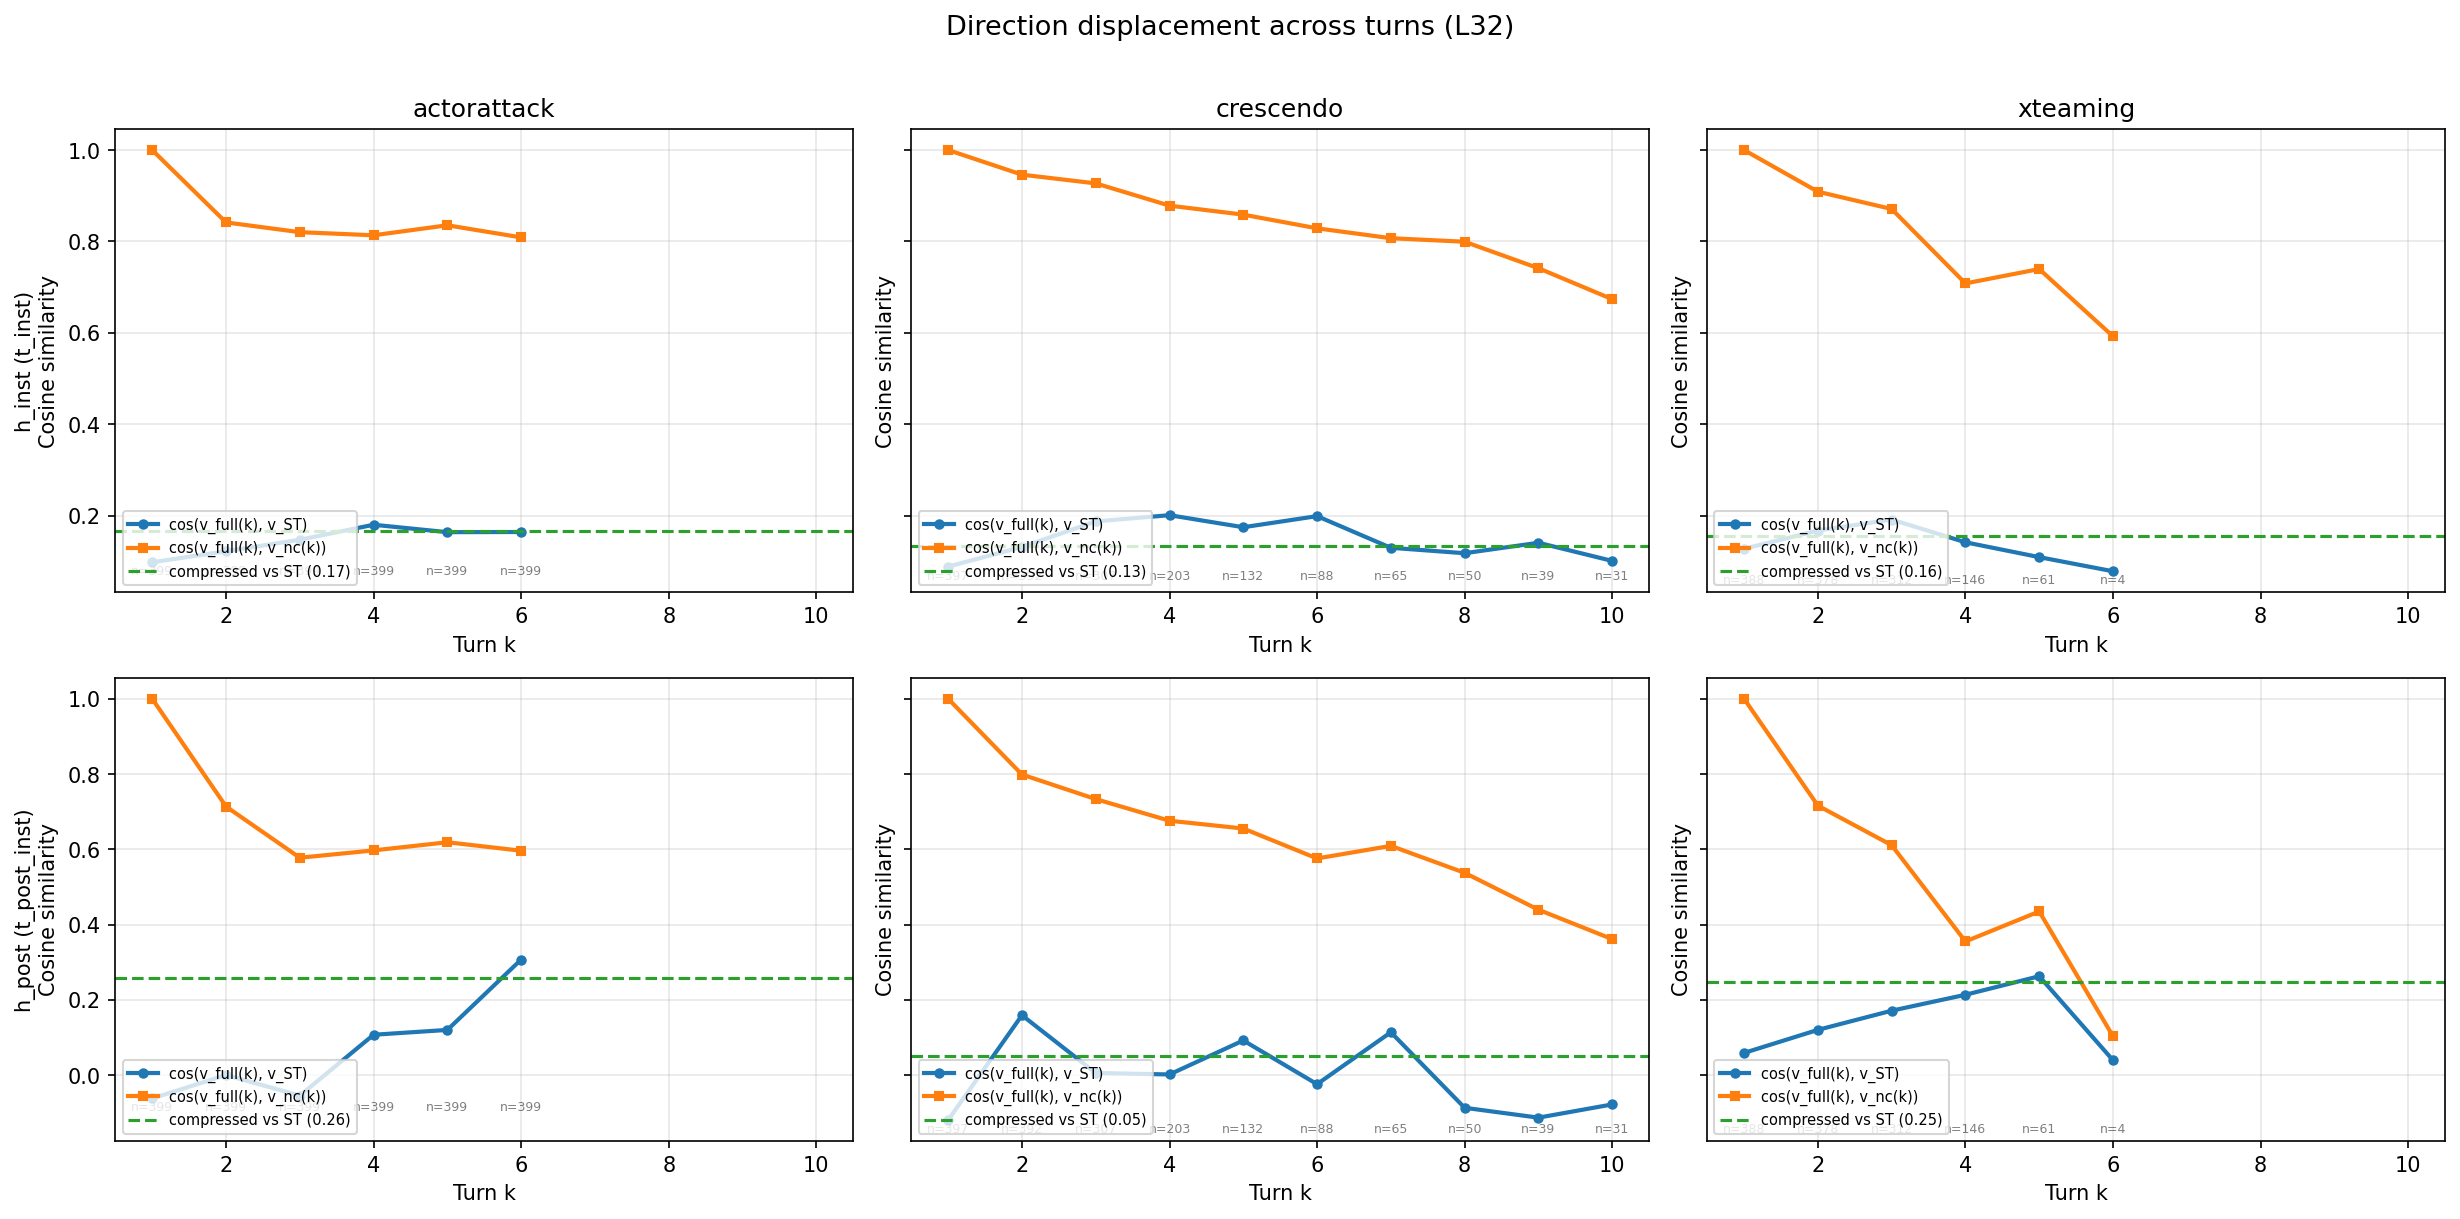

Saved: 08_fig1_direction_displacement.png


In [ ]:
L = FOCAL_LAYER  # shorthand

n_fw = len(avail_fw)
fig, axes = plt.subplots(2, max(n_fw, 1), figsize=(5.5 * max(n_fw, 1), 8),
                         squeeze=False, sharey="row")

v_st_dict = {"h_inst": v_st_inst, "h_post": v_st_post}

for col, fw in enumerate(avail_fw):
    for row, (h_key, pos_label) in enumerate([("h_inst", "h_inst (t_inst)"),
                                               ("h_post", "h_post (t_post_inst)")]):
        ax = axes[row, col]
        v_st_vec = v_st_dict[h_key][L]

        # ── Line 1: cos(v_full(k), v_ST) — drift from baseline ───────────
        ks, cos_drift, ns = [], [], []
        for k in range(1, MAX_K + 1):
            v = v_full.get((fw, h_key), {}).get(k)
            if v is None:
                continue
            ks.append(k)
            cos_drift.append(cosine(v[L], v_st_vec))
            counts = n_at_k.get((fw, h_key), {}).get(k, (0, 0))
            ns.append(min(counts))

        if ks:
            ax.plot(ks, cos_drift, "o-", color="#1f77b4", lw=2, ms=4,
                    label="cos(v_full(k), v_ST)")

        # ── Line 2: cos(v_full(k), v_nc(k)) — context contribution ───────
        if (fw, h_key) in v_nc:
            ks_nc, cos_ctx = [], []
            for k in range(1, MAX_K + 1):
                v_f = v_full.get((fw, h_key), {}).get(k)
                v_n = v_nc.get((fw, h_key), {}).get(k)
                if v_f is None or v_n is None:
                    continue
                ks_nc.append(k)
                cos_ctx.append(cosine(v_f[L], v_n[L]))
            if ks_nc:
                ax.plot(ks_nc, cos_ctx, "s-", color="#ff7f0e", lw=2, ms=4,
                        label="cos(v_full(k), v_nc(k))")

        # ── Line 3: compressed reference ──────────────────────────────────
        v_c = v_comp.get((fw, h_key))
        if v_c is not None:
            cos_comp = cosine(v_c[L], v_st_vec)
            ax.axhline(cos_comp, color="#2ca02c", ls="--", lw=1.5,
                       label=f"compressed vs ST ({cos_comp:.2f})")

        # ── Annotations ──────────────────────────────────────────────────
        if ks and ns:
            for x, n in zip(ks, ns):
                if n > 0:
                    ax.annotate(f"n={n}", (x, ax.get_ylim()[0]),
                                fontsize=6, ha="center", alpha=0.5,
                                textcoords="offset points", xytext=(0, 4))

        ax.set_xlabel("Turn k")
        ax.set_ylabel("Cosine similarity")
        if row == 0:
            ax.set_title(f"{fw}")
        if col == 0:
            ax.set_ylabel(f"{pos_label}\nCosine similarity")
        ax.legend(fontsize=7, loc="lower left")
        ax.set_xlim(0.5, MAX_K + 0.5)
        ax.grid(True, alpha=0.3)

fig.suptitle(f"Direction displacement across turns ({FOCAL_LAYER_LABEL})", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_fig1_direction_displacement.png")
plt.show()
print("Saved: 08_fig1_direction_displacement.png")

## Figure 2 — Detection failure and recovery

**H2 (Detection failure):** A classifier anchored to `v_harmful(ST)` degrades in AUROC
as turns accumulate, while a per-turn adaptive classifier maintains performance.

At each turn k, project held-out (test, attempts 17-20) hidden states onto:
- **Fixed:** `v_harmful(ST)` — what a single-turn defense would use
- **Adaptive:** `v_harmful_full(k)` — direction recomputed at this turn

The widening gap is the central result.

In [ ]:
def auroc_at_k(data_dict, fw, h_key, direction_vec, k):
    """
    Project test-split data at turn k onto direction_vec (4096,).
    Returns AUROC or np.nan if insufficient data.
    """
    d_h = data_dict.get((fw, "harmful"))
    d_b = data_dict.get((fw, "benign"))
    if d_h is None or d_b is None:
        return np.nan

    mask_h = (d_h["meta"]["turn_k"] == k) & (d_h["meta"]["data_split"] == "test")
    mask_b = (d_b["meta"]["turn_k"] == k) & (d_b["meta"]["data_split"] == "test")

    h_h = d_h[h_key][mask_h.values, L, :].astype(np.float32)
    h_b = d_b[h_key][mask_b.values, L, :].astype(np.float32)

    if len(h_h) < 5 or len(h_b) < 5:
        return np.nan

    proj_h = h_h @ direction_vec
    proj_b = h_b @ direction_vec

    labels = np.concatenate([np.ones(len(h_h)), np.zeros(len(h_b))])
    scores = np.concatenate([proj_h, proj_b])
    return roc_auc_score(labels, scores)

# ── Compute AUROC curves ─────────────────────────────────────────────────────
auroc_results = {}   # auroc_results[fw] = {"fixed": [...], "adaptive": [...], "ks": [...]}

for fw in avail_fw:
    v_st_vec = v_st_inst[L]
    ks, auc_fixed, auc_adaptive, ns = [], [], [], []

    for k in range(1, MAX_K + 1):
        v_adapt = v_full.get((fw, "h_inst"), {}).get(k)
        if v_adapt is None:
            continue

        af = auroc_at_k(traj, fw, "h_inst", v_st_vec, k)
        aa = auroc_at_k(traj, fw, "h_inst", v_adapt[L], k)

        if np.isnan(af) or np.isnan(aa):
            continue

        ks.append(k)
        auc_fixed.append(af)
        auc_adaptive.append(aa)

        counts = n_at_k.get((fw, "h_inst"), {}).get(k, (0, 0))
        ns.append(min(counts))

    auroc_results[fw] = {"ks": ks, "fixed": auc_fixed,
                         "adaptive": auc_adaptive, "ns": ns}
    print(f"  {fw}: AUROC computed at {len(ks)} turns")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, max(n_fw, 1), figsize=(5.5 * max(n_fw, 1), 4),
                         squeeze=False)

for col, fw in enumerate(avail_fw):
    ax = axes[0, col]
    r = auroc_results[fw]

    ax.plot(r["ks"], r["fixed"], "o-", color="#d62728", lw=2, ms=4,
            label="Fixed (v_ST)")
    ax.plot(r["ks"], r["adaptive"], "s-", color="#1f77b4", lw=2, ms=4,
            label="Adaptive (v_full(k))")

    # Shade the gap
    ax.fill_between(r["ks"], r["fixed"], r["adaptive"],
                    alpha=0.15, color="#1f77b4")

    # Sample size annotations
    for x, n in zip(r["ks"], r["ns"]):
        ax.annotate(f"n={n}", (x, 0.48), fontsize=6, ha="center", alpha=0.5)

    ax.set_xlabel("Turn k")
    ax.set_ylabel("AUROC")
    ax.set_title(fw)
    ax.legend(fontsize=8)
    ax.set_ylim(0.45, 1.02)
    ax.set_xlim(0.5, MAX_K + 0.5)
    ax.axhline(0.5, color="gray", ls=":", lw=0.8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Detection AUROC: fixed vs adaptive ({FOCAL_LAYER_LABEL})", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_fig2_detection_auroc.png")
plt.show()
print("Saved: 08_fig2_detection_auroc.png")

## Figure 3 — Behavioral correlation

**H3 (Behavioral correlation):** Turns where displacement is largest correspond
to the model's most cooperative behavioral responses.

For harmful conversations only, project each turn's hidden state onto
`v_harmful_full(k)` and split by the per-turn behavioral label
(`judge_success` = the model complied at this turn).

If the displacement is behaviourally meaningful, successful turns should
cluster at lower projections (less "harmful-looking" to the model).

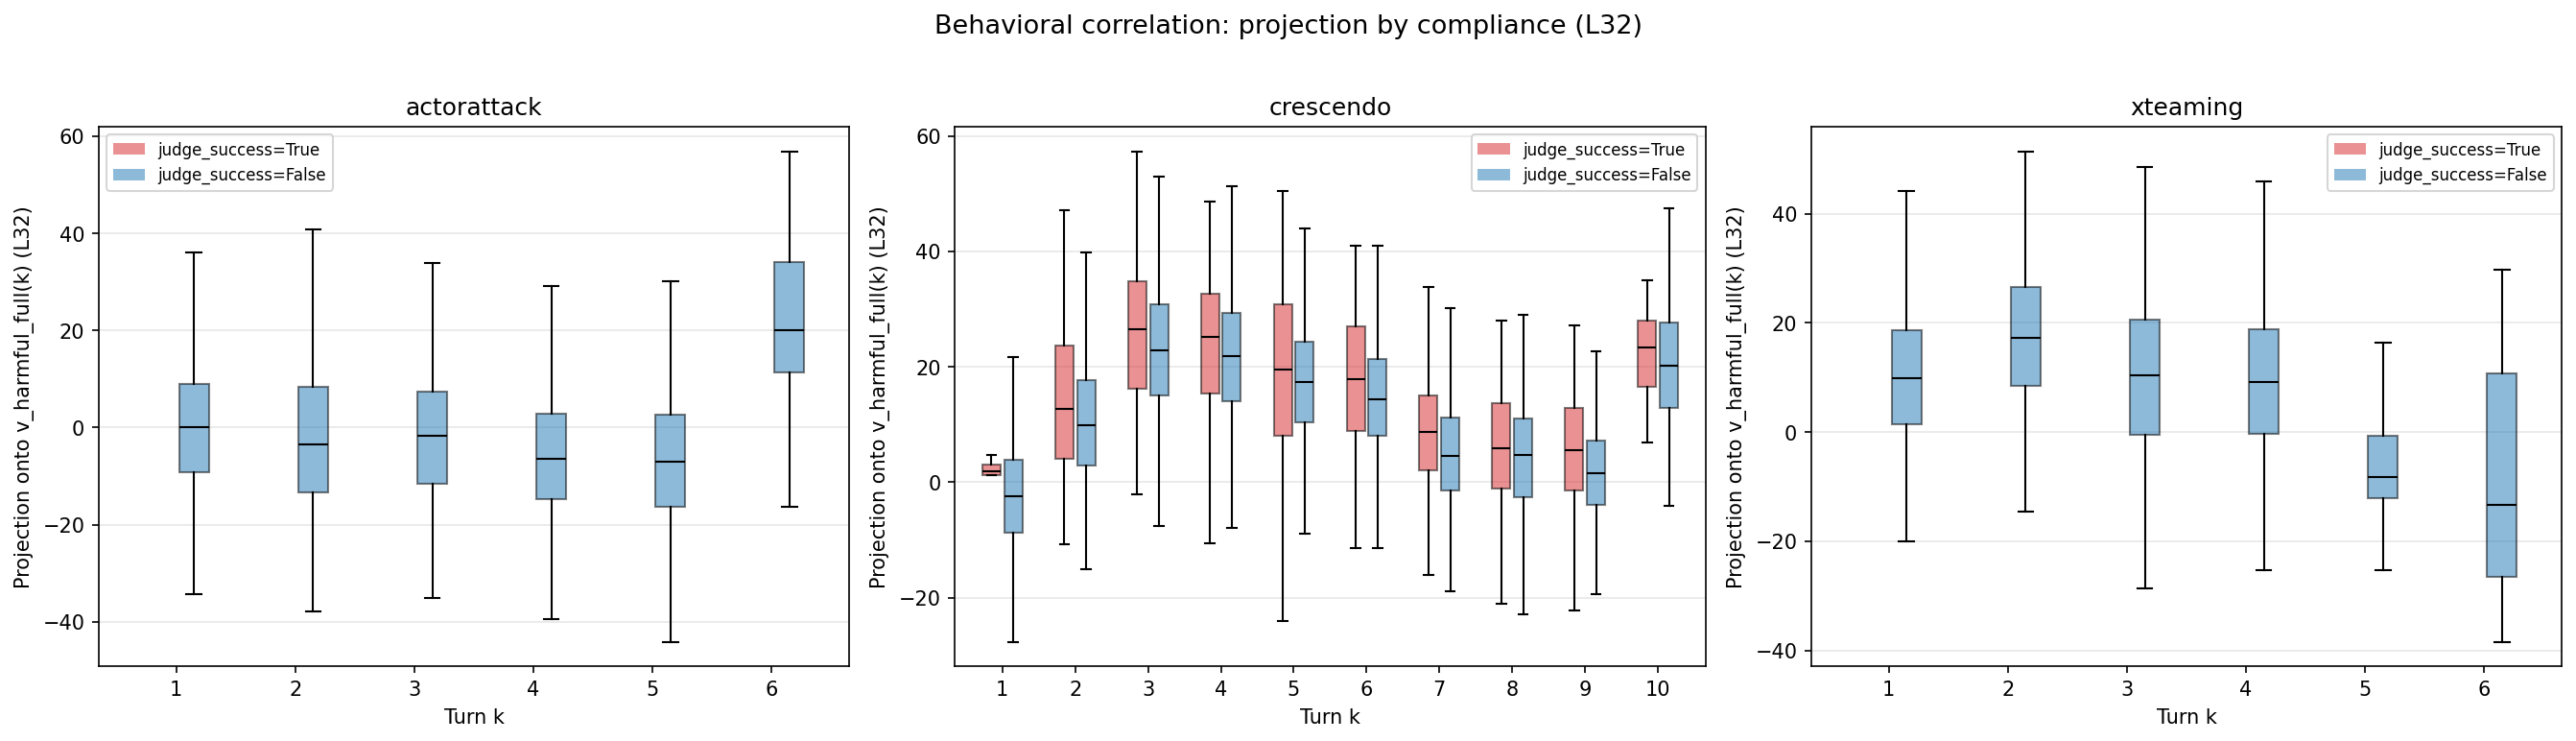

Saved: 08_fig3_behavioral_correlation.png


In [ ]:
# Only frameworks with per-turn behavioral labels (Crescendo has is_refusal/judge_success)
behav_fws = [fw for fw in avail_fw if fw in turn_labels and len(turn_labels[fw]) > 0]

if not behav_fws:
    print("No behavioral labels available -- skipping Figure 3.")
else:
    fig, axes = plt.subplots(1, len(behav_fws), figsize=(6 * len(behav_fws), 5),
                             squeeze=False)

    for col, fw in enumerate(behav_fws):
        ax = axes[0, col]
        d_h = traj.get((fw, "harmful"))
        if d_h is None:
            continue

        m_h = d_h["meta"]
        labels_df = turn_labels[fw]

        # Merge behavioral labels onto trajectory metadata
        m_merged = m_h.merge(
            labels_df, on=["pair_id", "attempt", "turn_k"], how="left"
        )

        # For each turn k, project onto v_full(k) and split by judge_success
        ks_plot = range(1, MAX_K + 1)
        proj_success, proj_nosuccess = {}, {}

        for k in ks_plot:
            v_k = v_full.get((fw, "h_inst"), {}).get(k)
            if v_k is None:
                continue

            mask_k = m_merged["turn_k"] == k
            rows_k = m_merged[mask_k]
            h_k = d_h["h_inst"][mask_k.values, L, :].astype(np.float32)

            if len(h_k) == 0:
                continue

            projections = h_k @ v_k[L]

            js = rows_k["judge_success"].values
            if js.sum() > 0:
                proj_success[k] = projections[js == True]
            if (~js).sum() > 0:
                proj_nosuccess[k] = projections[js == False]

        # Box plot
        valid_ks = sorted(set(proj_success.keys()) | set(proj_nosuccess.keys()))
        positions_s = [k - 0.15 for k in valid_ks]
        positions_n = [k + 0.15 for k in valid_ks]

        bp_s = ax.boxplot(
            [proj_success.get(k, []) for k in valid_ks],
            positions=positions_s, widths=0.25,
            patch_artist=True, showfliers=False,
            boxprops=dict(facecolor="#d62728", alpha=0.5),
            medianprops=dict(color="black"),
        )
        bp_n = ax.boxplot(
            [proj_nosuccess.get(k, []) for k in valid_ks],
            positions=positions_n, widths=0.25,
            patch_artist=True, showfliers=False,
            boxprops=dict(facecolor="#1f77b4", alpha=0.5),
            medianprops=dict(color="black"),
        )

        ax.set_xticks(valid_ks)
        ax.set_xticklabels(valid_ks)
        ax.set_xlabel("Turn k")
        ax.set_ylabel(f"Projection onto v_harmful_full(k) ({FOCAL_LAYER_LABEL})")
        ax.set_title(fw)

        # Legend
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(facecolor="#d62728", alpha=0.5, label="judge_success=True"),
            Patch(facecolor="#1f77b4", alpha=0.5, label="judge_success=False"),
        ], fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle(f"Behavioral correlation: projection by compliance ({FOCAL_LAYER_LABEL})",
                 y=1.02, fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "08_fig3_behavioral_correlation.png")
    plt.show()
    print("Saved: 08_fig3_behavioral_correlation.png")

## Summary table

Print a compact summary of the key metrics for quick reference.

In [ ]:
# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Framework':<14} {'k':>3}  {'cos(v_full,v_ST)':>17}  {'AUROC fixed':>12}  {'AUROC adaptive':>15}")
print("-" * 70)

for fw in avail_fw:
    v_st_vec = v_st_inst[L]
    r = auroc_results.get(fw, {})
    ks = r.get("ks", [])

    for k in [1, 3, 5, 8]:
        v_k = v_full.get((fw, "h_inst"), {}).get(k)
        if v_k is None:
            continue

        cos_val = cosine(v_k[L], v_st_vec)
        idx = ks.index(k) if k in ks else None
        af = r["fixed"][idx] if idx is not None else float("nan")
        aa = r["adaptive"][idx] if idx is not None else float("nan")

        print(f"{fw:<14} {k:>3}  {cos_val:>17.3f}  {af:>12.3f}  {aa:>15.3f}")
    print()

Framework        k   cos(v_full,v_ST)   AUROC fixed   AUROC adaptive
----------------------------------------------------------------------
actorattack      1              0.098         0.552            0.609
actorattack      3              0.147         0.543            0.567
actorattack      5              0.164         0.577            0.601

crescendo        1              0.088         0.584            0.694
crescendo        3              0.187         0.599            0.741
crescendo        5              0.174         0.612            0.746
crescendo        8              0.118         0.603            0.761

xteaming         1              0.127         0.558            0.661
xteaming         3              0.191         0.620            0.689
xteaming         5              0.109         0.573            0.705



## Figure 4 — Misbehavior clustering (Zhao et al. replication)

Zhao et al. validated t_inst and t_post by checking where “misbehaviors” cluster:
- At **t_inst** (h_inst): accepted-harmful clustered with refused-harmful (model
  internally encodes them as harmful regardless of behavioral outcome)
- At **t_post** (h_post): refused-harmless clustered with refused-harmful (position
  tracks refusal behavior, not harmfulness)

**Multi-turn question:** Does this separation hold as context accumulates?

For each turn k, we take the three groups — **accepted_harmful** (attack_success=True),
**refused_harmful** (attack_success=False), and **benign** — and ask:
1. **PCA scatter** at the final turn: where does refused_harmful sit?
2. **Nearest-centroid fraction** across turns: what fraction of refused_harmful samples
   are closer to the accepted_harmful centroid vs. the benign centroid?

If at later turns refused_harmful starts clustering with benign at h_inst, it means
the model no longer “sees” these conversations as harmful at that position — the
position is encoding something other than harmfulness.

In [ ]:
from sklearn.decomposition import PCA

# ── Helper: get final-turn representations split into 3 groups ────────────────
def get_three_groups(fw, h_key, layer):
    """
    Returns (h_acc, h_ref, h_ben) at the final turn of each conversation.
    h_acc: accepted_harmful, h_ref: refused_harmful, h_ben: benign
    """
    d_h = traj.get((fw, 'harmful'))
    d_b = traj.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return None

    m_h = d_h['meta']
    # Final turn per conversation — get positional indices into the array
    final_pos_h = m_h.groupby('conversation_id')['turn_k'].idxmax().values
    m_final_h = m_h.loc[final_pos_h].reset_index(drop=True)
    h_final_h = d_h[h_key][final_pos_h, layer, :].astype(np.float32)

    acc_mask = m_final_h['attack_success'].values == True
    ref_mask = m_final_h['attack_success'].values == False

    h_acc = h_final_h[acc_mask]
    h_ref = h_final_h[ref_mask]

    m_b = d_b['meta']
    final_pos_b = m_b.groupby('conversation_id')['turn_k'].idxmax().values
    h_ben = d_b[h_key][final_pos_b, layer, :].astype(np.float32)

    return h_acc, h_ref, h_ben

# ── Figure 4a: PCA scatter at final turn ─────────────────────────────────────
fig, axes = plt.subplots(2, max(n_fw, 1), figsize=(5.5 * max(n_fw, 1), 9),
                         squeeze=False)

COLORS = {'accepted_harmful': '#d62728', 'refused_harmful': '#ff9896',
          'benign': '#2ca02c'}

for col, fw in enumerate(avail_fw):
    for row, (h_key, pos_label) in enumerate([('h_inst', 'h_inst (t_inst)'),
                                              ('h_post', 'h_post (t_post_inst)')]):
        ax = axes[row, col]
        groups = get_three_groups(fw, h_key, L)
        if groups is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            continue

        h_acc, h_ref, h_ben = groups

        # PCA on all three groups together
        all_h = np.concatenate([h_acc, h_ref, h_ben], axis=0)
        pca = PCA(n_components=2)
        coords = pca.fit_transform(all_h)

        n_a, n_r, n_b = len(h_acc), len(h_ref), len(h_ben)
        c_a = coords[:n_a]
        c_r = coords[n_a:n_a + n_r]
        c_b = coords[n_a + n_r:]

        ax.scatter(c_b[:, 0], c_b[:, 1], c=COLORS['benign'],
                   alpha=0.3, s=8, label=f'benign (n={n_b})', zorder=1)
        ax.scatter(c_a[:, 0], c_a[:, 1], c=COLORS['accepted_harmful'],
                   alpha=0.3, s=8, label=f'accepted_harmful (n={n_a})', zorder=2)
        ax.scatter(c_r[:, 0], c_r[:, 1], c=COLORS['refused_harmful'],
                   alpha=0.6, s=12, label=f'refused_harmful (n={n_r})', zorder=3)

        ev = pca.explained_variance_ratio_
        ax.set_xlabel(f'PC1 ({ev[0]:.1%})')
        ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
        if row == 0:
            ax.set_title(fw)
        if col == 0:
            ax.set_ylabel(f'{pos_label}\nPC2 ({ev[1]:.1%})')
        ax.legend(fontsize=6, markerscale=2)

fig.suptitle(f'Misbehavior clustering at final turn ({FOCAL_LAYER_LABEL})', y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_fig4a_misbehavior_pca.png')
plt.show()
print('Saved: 08_fig4a_misbehavior_pca.png')

In [ ]:
# ── Figure 4b: Nearest-centroid fraction across turns ─────────────────────────
#
# At each turn k, for each refused_harmful sample, compute:
#   d_harm = ||h - centroid(accepted_harmful)||
#   d_ben  = ||h - centroid(benign)||
# Report the fraction that are closer to accepted_harmful centroid.
#
# Zhao et al. prediction (single-turn): at h_inst, refused_harmful should cluster
# with accepted_harmful (both "seen as harmful").  Fraction ~ 1.0.
# Displacement prediction: this fraction may drop at later turns.

def nearest_centroid_at_k(fw, h_key, layer, k):
    """
    At turn k, compute fraction of refused_harmful closer to
    accepted_harmful centroid than to benign centroid.
    Returns (fraction, n_refused) or (None, 0).
    """
    d_h = traj.get((fw, 'harmful'))
    d_b = traj.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return None, 0

    m_h = d_h['meta']
    m_b = d_b['meta']

    # All harmful at turn k
    mask_k = m_h['turn_k'] == k
    m_k = m_h[mask_k]
    h_k = d_h[h_key][mask_k.values, layer, :].astype(np.float32)

    acc_mask = m_k['attack_success'] == True
    ref_mask = m_k['attack_success'] == False

    h_acc = h_k[acc_mask.values]
    h_ref = h_k[ref_mask.values]

    if len(h_acc) < 5 or len(h_ref) < 5:
        return None, len(h_ref)

    # Benign at turn k
    mask_b_k = m_b['turn_k'] == k
    h_ben = d_b[h_key][mask_b_k.values, layer, :].astype(np.float32)

    if len(h_ben) < 5:
        return None, len(h_ref)

    centroid_acc = h_acc.mean(axis=0)
    centroid_ben = h_ben.mean(axis=0)

    d_to_acc = np.linalg.norm(h_ref - centroid_acc, axis=1)
    d_to_ben = np.linalg.norm(h_ref - centroid_ben, axis=1)

    frac_closer_to_harmful = (d_to_acc < d_to_ben).mean()
    return frac_closer_to_harmful, len(h_ref)

fig, axes = plt.subplots(2, max(n_fw, 1), figsize=(5.5 * max(n_fw, 1), 8),
                         squeeze=False, sharey='row')

for col, fw in enumerate(avail_fw):
    for row, (h_key, pos_label) in enumerate([('h_inst', 'h_inst (t_inst)'),
                                              ('h_post', 'h_post (t_post_inst)')]):
        ax = axes[row, col]

        ks, fracs, ns = [], [], []
        for k in range(1, MAX_K + 1):
            f, n = nearest_centroid_at_k(fw, h_key, L, k)
            if f is None:
                continue
            ks.append(k)
            fracs.append(f)
            ns.append(n)

        if ks:
            ax.plot(ks, fracs, 'o-', color='#d62728', lw=2, ms=5)
            ax.axhline(0.5, color='gray', ls=':', lw=0.8, label='chance')

            # Annotate sample sizes
            for x, n in zip(ks, ns):
                ax.annotate(f'n={n}', (x, 0.02), fontsize=6, ha='center', alpha=0.5)

        ax.set_xlabel('Turn k')
        if row == 0:
            ax.set_title(fw)
        if col == 0:
            ax.set_ylabel(f'{pos_label}\nFrac closer to harmful centroid')
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(0.5, MAX_K + 0.5)
        ax.grid(True, alpha=0.3)

fig.suptitle(
    f'Refused-harmful: nearest centroid (harmful vs benign) across turns ({FOCAL_LAYER_LABEL})\n'
    f'1.0 = clusters with harmful (Zhao et al. single-turn prediction), '
    f'0.5 = chance',
    y=1.03, fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_fig4b_nearest_centroid.png')
plt.show()
print('Saved: 08_fig4b_nearest_centroid.png')

In [ ]:
# ── Figure 4c: Nearest-centroid sensitivity across layers ─────────────────────
# Precompute centroids once, then reuse for all queries.

CHECK_LAYERS = VERIFY_LAYERS      # use full sweep (8 proportional layers)
CHECK_LABELS = VERIFY_LABELS
LAYER_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# ── Precompute per-(fw, h_key, layer, k) centroids and refused arrays ────────
print('Precomputing centroids...', flush=True)
centroids = {}   # (fw, h_key, layer, k) -> (centroid_acc, centroid_ben, h_ref)

for fw in avail_fw:
    d_h = traj.get((fw, 'harmful'))
    d_b = traj.get((fw, 'benign'))
    if d_h is None or d_b is None:
        continue

    m_h, m_b = d_h['meta'], d_b['meta']

    for h_key in ['h_inst', 'h_post']:
        # Load full arrays as float32 once per (fw, h_key)
        arr_h = d_h[h_key]  # (N, 32, 4096) float16
        arr_b = d_b[h_key]

        for k in range(1, MAX_K + 1):
            mask_h_k = (m_h['turn_k'] == k).values
            mask_b_k = (m_b['turn_k'] == k).values

            if mask_h_k.sum() == 0 or mask_b_k.sum() == 0:
                continue

            m_h_k = m_h[mask_h_k]
            acc_mask = m_h_k['attack_success'].values == True
            ref_mask = ~acc_mask

            if acc_mask.sum() < 5 or ref_mask.sum() < 5:
                continue

            # Slice once per k — all layers at once
            h_k_all = arr_h[mask_h_k]   # (n_harm_k, 32, 4096)
            b_k_all = arr_b[mask_b_k]   # (n_ben_k, 32, 4096)

            for li in CHECK_LAYERS:
                h_acc_l = h_k_all[acc_mask, li, :].astype(np.float32)
                h_ref_l = h_k_all[ref_mask, li, :].astype(np.float32)
                h_ben_l = b_k_all[:, li, :].astype(np.float32)

                centroids[(fw, h_key, li, k)] = (
                    h_acc_l.mean(axis=0),
                    h_ben_l.mean(axis=0),
                    h_ref_l,
                )

    print(f'  {fw}: done', flush=True)

print(f'Centroids cached: {len(centroids)} entries')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, max(n_fw, 1), figsize=(5.5 * max(n_fw, 1), 8),
                         squeeze=False, sharey='row')

for col, fw in enumerate(avail_fw):
    for row, (h_key, pos_label) in enumerate([('h_inst', 'h_inst (t_inst)'),
                                              ('h_post', 'h_post (t_post_inst)')]):
        ax = axes[row, col]

        for li, ll, lc in zip(CHECK_LAYERS, CHECK_LABELS, LAYER_COLORS):
            ks, fracs = [], []
            for k in range(1, MAX_K + 1):
                entry = centroids.get((fw, h_key, li, k))
                if entry is None:
                    continue
                c_acc, c_ben, h_ref = entry
                d_to_acc = np.linalg.norm(h_ref - c_acc, axis=1)
                d_to_ben = np.linalg.norm(h_ref - c_ben, axis=1)
                ks.append(k)
                fracs.append((d_to_acc < d_to_ben).mean())

            if ks:
                ax.plot(ks, fracs, 'o-', color=lc, lw=1.5, ms=4, label=ll)

        ax.axhline(0.5, color='gray', ls=':', lw=0.8)
        ax.set_xlabel('Turn k')
        if row == 0:
            ax.set_title(fw)
        if col == 0:
            ax.set_ylabel(f'{pos_label}\nFrac closer to harmful centroid')
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlim(0.5, MAX_K + 0.5)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

fig.suptitle(
    'Nearest-centroid fraction across layers\n'
    '1.0 = refused_harmful clusters with harmful (Zhao et al.), 0.5 = chance',
    y=1.03, fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_fig4c_nearest_centroid_layers.png')
plt.show()
print('Saved: 08_fig4c_nearest_centroid_layers.png')

### Figure 4d — Clustering by extraction condition

Same PCA analysis but comparing across extraction conditions at the final turn:
- **Full-context** (trajectory): model has all prior turns in context
- **No-context**: model sees only the final attacker message in isolation
- **Single-turn baseline**: raw JBB goal, no attack framing at all

If Zhao et al.’s clean clustering reappears in no-context/single-turn but is
muddled in full-context, that directly shows **context accumulation** is what
destroys the harmfulness signal at these positions.

In [ ]:
# ── Figure 4d: Clustering comparison across extraction conditions ─────────────
#
# Rows: h_inst, h_post
# Columns: full-context (traj), no-context, single-turn
# (one framework at a time — use Crescendo as primary)

FW_FOCUS = 'crescendo'  # primary framework

def get_three_groups_from(data_dict, fw, h_key, layer, final_turn=True):
    """
    Like get_three_groups but works with any data dict (traj, nc, etc).
    If final_turn=True, takes the last turn per conversation.
    If final_turn=False (e.g. single-turn), takes all rows.
    """
    d_h = data_dict.get((fw, 'harmful'))
    d_b = data_dict.get((fw, 'benign'))
    if d_h is None or d_b is None:
        return None

    m_h = d_h['meta']
    if final_turn and 'turn_k' in m_h.columns:
        pos_h = m_h.groupby('conversation_id')['turn_k'].idxmax().values
    else:
        pos_h = np.arange(len(m_h))
    m_sel_h = m_h.iloc[pos_h] if not final_turn else m_h.loc[pos_h]
    h_all_h = d_h[h_key][pos_h, layer, :].astype(np.float32)

    if 'attack_success' in m_sel_h.columns:
        acc_mask = m_sel_h['attack_success'].values == True
        ref_mask = ~acc_mask
    else:
        # No attack_success (e.g. single-turn) — all harmful are one group
        acc_mask = np.ones(len(m_sel_h), dtype=bool)
        ref_mask = np.zeros(len(m_sel_h), dtype=bool)

    h_acc = h_all_h[acc_mask]
    h_ref = h_all_h[ref_mask]

    m_b = d_b['meta']
    if final_turn and 'turn_k' in m_b.columns:
        pos_b = m_b.groupby('conversation_id')['turn_k'].idxmax().values
    else:
        pos_b = np.arange(len(m_b))
    h_ben = d_b[h_key][pos_b, layer, :].astype(np.float32)

    return h_acc, h_ref, h_ben

def get_st_groups(h_key, layer):
    """Single-turn: all harmful vs all benign (no accepted/refused split)."""
    h_harm = st['harmful'][h_key][:, layer, :].astype(np.float32)
    h_ben  = st['benign'][h_key][:, layer, :].astype(np.float32)
    # Return as (harmful, empty_refused, benign)
    return h_harm, np.empty((0, h_harm.shape[1]), dtype=np.float32), h_ben

# Build the conditions to compare
conditions = [('Full-context\n(trajectory)', lambda hk, ly: get_three_groups_from(traj, FW_FOCUS, hk, ly))]

if (FW_FOCUS, 'harmful') in nc:
    conditions.append(('No-context\n(isolated msg)', lambda hk, ly: get_three_groups_from(nc, FW_FOCUS, hk, ly)))

conditions.append(('Single-turn\n(raw JBB goal)', lambda hk, ly: get_st_groups(hk, ly)))

n_cond = len(conditions)

fig, axes = plt.subplots(2, n_cond, figsize=(5.5 * n_cond, 9), squeeze=False)

for col, (cond_label, get_fn) in enumerate(conditions):
    for row, (h_key, pos_label) in enumerate([('h_inst', 'h_inst (t_inst)'),
                                              ('h_post', 'h_post (t_post_inst)')]):
        ax = axes[row, col]
        groups = get_fn(h_key, L)
        if groups is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes)
            continue

        h_acc, h_ref, h_ben = groups

        # PCA on all available groups
        parts = [p for p in [h_acc, h_ref, h_ben] if len(p) > 0]
        all_h = np.concatenate(parts, axis=0)
        pca = PCA(n_components=2)
        coords = pca.fit_transform(all_h)

        # Split coords back
        idx = 0
        if len(h_acc) > 0:
            c_a = coords[idx:idx + len(h_acc)]
            idx += len(h_acc)
            ax.scatter(c_a[:, 0], c_a[:, 1], c=COLORS['accepted_harmful'],
                       alpha=0.3, s=8, zorder=2,
                       label=f'accepted_harmful (n={len(h_acc)})' if len(h_ref) > 0 else f'harmful (n={len(h_acc)})')
        if len(h_ref) > 0:
            c_r = coords[idx:idx + len(h_ref)]
            idx += len(h_ref)
            ax.scatter(c_r[:, 0], c_r[:, 1], c=COLORS['refused_harmful'],
                       alpha=0.6, s=12, zorder=3,
                       label=f'refused_harmful (n={len(h_ref)})')
        if len(h_ben) > 0:
            c_b = coords[idx:idx + len(h_ben)]
            ax.scatter(c_b[:, 0], c_b[:, 1], c=COLORS['benign'],
                       alpha=0.3, s=8, zorder=1,
                       label=f'benign (n={len(h_ben)})')

        ev = pca.explained_variance_ratio_
        ax.set_xlabel(f'PC1 ({ev[0]:.1%})')
        ax.set_ylabel(f'PC2 ({ev[1]:.1%})')
        if row == 0:
            ax.set_title(cond_label)
        if col == 0:
            ax.set_ylabel(f'{pos_label}\nPC2 ({ev[1]:.1%})')
        ax.legend(fontsize=6, markerscale=2)

fig.suptitle(f'{FW_FOCUS} — Misbehavior clustering by extraction condition ({FOCAL_LAYER_LABEL})',
             y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_fig4d_clustering_by_condition.png')
plt.show()
print('Saved: 08_fig4d_clustering_by_condition.png')